# **Off-policy MC Control for Action Value Function Prediction (First Visit)**

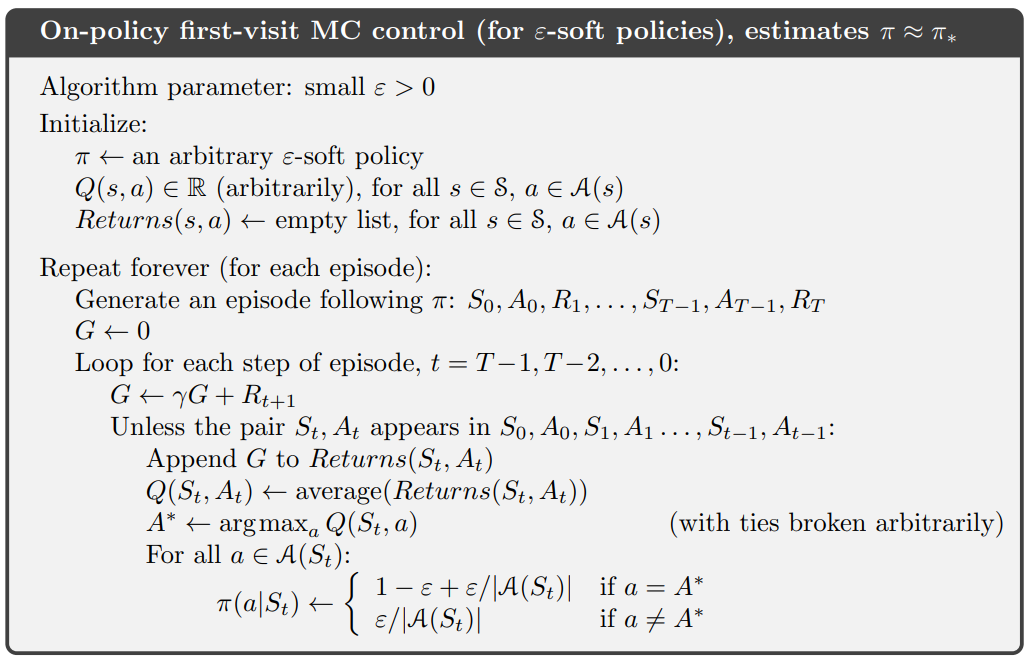

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import random

# **Functions**

In [ ]:
def Environment(AllStates, State, Action, Goal):

  Row = State[0]
  Col = State[1]

  RowV = Action[0]
  ColV = Action[1]

  NewState = np.array([Row + RowV, Col + ColV])

  if np.any(np.all(AllStates == NewState, axis=1)):
    if np.all(Goal == NewState):
      Reward = 10
    else:
      Reward = -1
  else:
    Reward = -10
    NewState = np.array([Row, Col])


  if np.all(Goal == np.array([Row, Col])):
    Reward = 0
    NewState = np.array([Row, Col])


  return NewState, Reward


#################################################################################
def PolicyImprovement_Q(Q, AllActions, epsilon):

  # Policy ########################################################
  nStates = Q.shape[0] // AllActions.shape[0]
  BestPolicy = np.zeros(nStates, dtype=int)


  for i in range(nStates):
    BestPolicy[i] = np.argmax(Q[4*i:4*(i+1)])

  return BestPolicy

# **Create the environment with code (without gym library)**
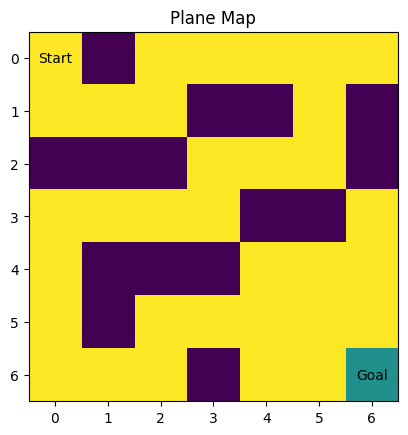

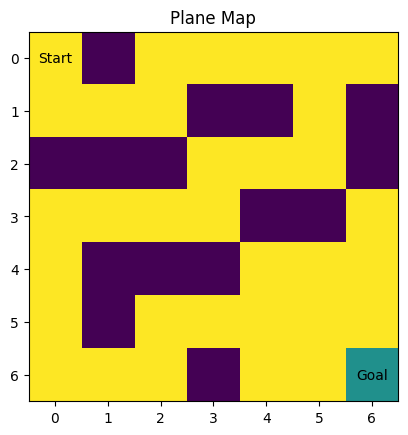

In [ ]:
PlaneSized = 7
OneStates = []
Gamma = 0.99
InitialStates = np.array([0, 0])

Plane = np.ones((PlaneSized, PlaneSized)) # 1 means free and 0 means barrier
barriers = [
    (0, 1),
    (1, 3), (1, 4), (1, 6),
    (2, 0), (2, 1), (2, 2), (2, 6),
    (3, 4), (3, 5),
    (4, 1), (4, 2), (4, 3),
    (5, 1),
    (6, 3)
]
Goal = np.array([6, 6])
for r, c in barriers:
    Plane[r, c] = 0

for i in range(PlaneSized):
  for j in range(PlaneSized):
    if Plane[i, j] == 1:
      OneStates.append([i, j])


AllActions = np.array([[1, 0], [-1, 0], [0, 1], [0, -1]]) # [1, 0]: Down_0, [-1, 0]: Up_1, [0, 1]: Right_2, [0, -1]: Left_3
AllStates = np.array(OneStates)

Plane[Goal[0], Goal[1]] = 0.5

plt.imshow(Plane)
plt.text(Goal[1], Goal[0], 'Goal', fontsize=10, color='Black', ha='center', va='center')
plt.text(0, 0, 'Start', fontsize=10, color='Black', ha='center', va='center')
plt.title("Plane Map")
plt.xticks(range(PlaneSized))
plt.yticks(range(PlaneSized))
plt.show()

# **Off-policy MC Control for Action Value Function Prediction (First Visit)**

In [ ]:
AllStatesActions = np.zeros((AllStates.shape[0]*AllActions.shape[0], 4), dtype=int)

step = 0

for i in range(AllStates.shape[0]):

  for j in range(AllActions.shape[0]):

    AllStatesActions[step] = np.concatenate((AllStates[i], AllActions[j]))

    step+= 1


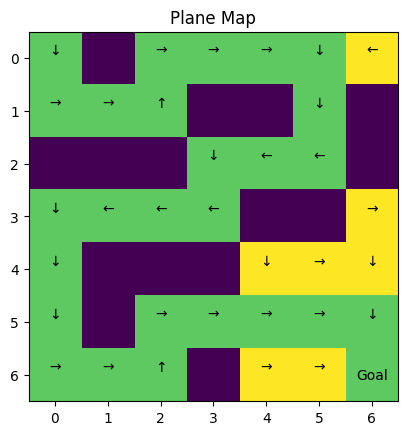

In [ ]:
Policy = np.random.randint(0, AllActions.shape[0], size=AllStates.shape[0])
Number = np.zeros(AllStatesActions.shape[0])
Q = np.zeros(AllStatesActions.shape[0])

k = 5000
episod = 300
policy_stable = 1
stop_step = 0
epsilon = 0.9


for i in range(episod):
  RewardAll = []
  VisitedPair = []
  FirstStep = 0
  Current_State = InitialStates.copy()
  for j in range(k):

    if np.random.rand() > epsilon:
      CurrentStateIndex = np.where(np.all(AllStates == Current_State , axis=1))[0][0]
      PolicyActionIndex =Policy[CurrentStateIndex]
      PolicyAction = AllActions[PolicyActionIndex]
    else:
      PolicyRandom = np.random.randint(AllActions.shape[0])
      PolicyAction = AllActions[PolicyRandom]


    NewState, Reward = Environment(AllStates, Current_State, PolicyAction, Goal)

    VisitedPair.append(np.concatenate((Current_State, PolicyAction)))

    RewardAll.append(Reward)
    Current_State = NewState



    if(np.array_equal(Current_State, Goal)):
      break

  VisitedPair = np.array(VisitedPair, dtype=int)


  for m in range(AllStatesActions.shape[0]):

    if(np.array_equal(AllStatesActions[m][:2], Goal)):
      continue

    # print(np.all(ActionAll == AllStates[m] , axis=1))

    indices = np.where(np.all(VisitedPair == AllStatesActions[m], axis=1))[0]

    if indices.size == 0:
      continue

    # First Visit
    FirstVisit = indices[0]

    Number[m] = Number[m] + 1

    Return = 0
    for n in range(FirstVisit, len(RewardAll)):
      Return += RewardAll[n] * Gamma**(n - FirstVisit)

    # For Stationary Environment
    Q[m] = Q[m] + (1/Number[m]) * (Return - Q[m])


    # For Non-tationary Environment (Constant alpha MC)
    # Q[m] = Q[m] + 0.1 * (Return - Q[m])



  Policy = PolicyImprovement_Q(Q, AllActions, epsilon)
  # print(Policy)

  epsilon = epsilon * 0.97


# Down_0, Up_1, Right_2, Left_3
directionPolicy = np.empty(Policy.shape[0], dtype=object)
for i in range(Policy.shape[0]):
  if Policy[i] == 0:
    directionPolicy[i] = '↓'
  elif Policy[i] == 1:
    directionPolicy[i] = '↑'
  elif Policy[i] == 2:
    directionPolicy[i] = '→'
  else:
    directionPolicy[i] = '←'


Plane2 = Plane.copy()
plt.imshow(Plane2)


Plane2[InitialStates[0], InitialStates[1]]= 0.75
plt.imshow(Plane2)


for i in range(Policy.size-1):
  MovingInPlaneIndex = np.where(np.all(AllStates == InitialStates , axis=1))
  InitialStatesNext = InitialStates + AllActions[Policy[MovingInPlaneIndex]]
  InitialStates = InitialStatesNext
  Plane2[InitialStatesNext[0][0], InitialStatesNext[0][1]]= 0.75
  plt.imshow(Plane2)

  if np.all(Goal == InitialStatesNext , axis=1):
    break



for i in range(Policy.size-1):
  plt.text(AllStates[i][1], AllStates[i][0] - 0.15, directionPolicy[i], fontsize=10, color='Black', ha='center', va='center')


plt.text(Goal[1], Goal[0], 'Goal', fontsize=10, color='Black', ha='center', va='center')

plt.title("Plane Map")
plt.xticks(range(PlaneSized))
plt.yticks(range(PlaneSized))
plt.show()